### import needed packages and read the combined dataset

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
import re
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

In [50]:
# Load the unified email dataset
email_df = pd.read_csv('datasets/processed/combined_dataset.csv')

print(f"Total Records: {email_df.shape[0]:,}")
print(f"Total Features: {email_df.shape[1]}")
print(f"Memory Usage: {email_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumns:", list(email_df.columns))


Total Records: 114,578
Total Features: 8
Memory Usage: 303.54 MB

Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'source_dataset']


### We will deal with our data in this exact order
1. Label distribution - Understand class balance first (critical for phishing detection)
2. Duplicates - Remove exact/near duplicates early
3. Data quality issues - Invalid entries, malformed data, inconsistencies
4. Text-specific cleaning - Remove empty bodies, weird encoding, etc.
5. Missing data - Handle nulls LAST (after removing junk rows)

1. Label distribution - Understand class balance first (critical for phishing detection)


Overall Label Distribution:
Label 0: 50,260 (43.87%)
Label 1: 64,318 (56.13%)


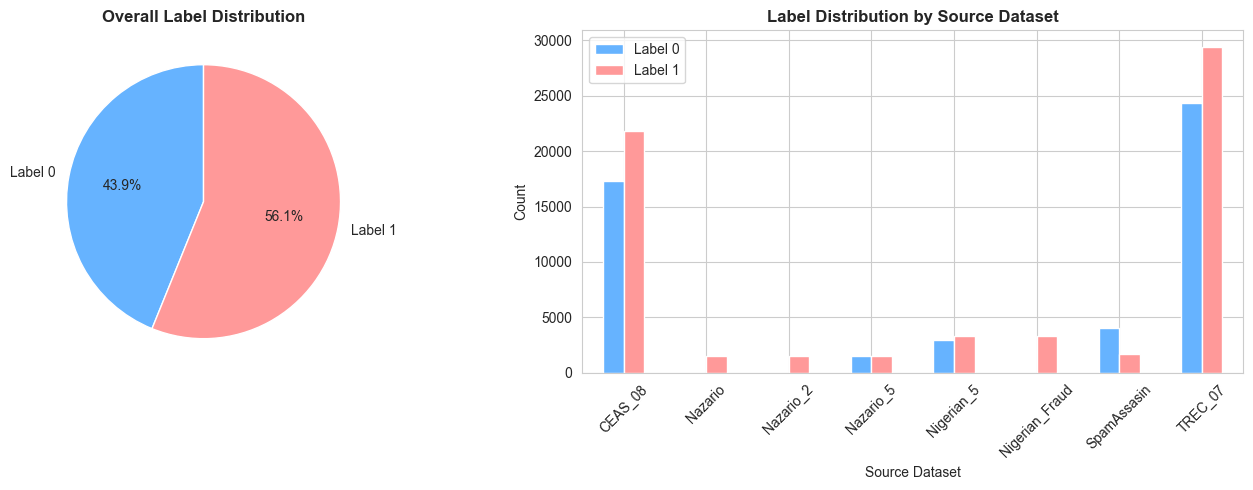

In [51]:
# Overall label distribution
label_counts = email_df['label'].value_counts().sort_index()
label_pct = (email_df['label'].value_counts(normalize=True).sort_index() * 100).round(2)

print("\nOverall Label Distribution:")
print(f"Label 0: {label_counts.get(0, 0):,} ({label_pct.get(0, 0)}%)")
print(f"Label 1: {label_counts.get(1, 0):,} ({label_pct.get(1, 0)}%)")

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(label_counts, labels=[f'Label {i}' for i in label_counts.index],
            autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
axes[0].set_title('Overall Label Distribution', fontsize=12, fontweight='bold')

# Bar chart by source dataset
label_by_source = email_df.groupby(['source_dataset', 'label']).size().unstack(fill_value=0)
label_by_source.plot(kind='bar', ax=axes[1], color=['#66b3ff', '#ff9999'])
axes[1].set_title('Label Distribution by Source Dataset', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Source Dataset')
axes[1].set_ylabel('Count')
axes[1].legend(['Label 0', 'Label 1'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#### Key Findings:
1. Reasonably balanced: 56.1% phishing (Label 1) vs 43.9% legitimate (Label 0)
2. CEAS_08 & TREC_07 dominate the dataset (largest bars)
3. Nazario variants are almost entirely phishing (Label 1)
4. Nigerian_Fraud is 100% phishing
5. Good mix across sources

2. Duplicates - Remove exact/near duplicates early


Exact Duplicates (all columns): 0 (0.00%)

Duplicates by Key Columns:
  body: 16660 (14.54%)
  subject: 75346 (65.76%)
  subject + body: 16659 (14.54%)
  sender + subject + body: 16658 (14.54%)

----------------------------------------------------------------------
Duplicate Distribution Across Sources:
----------------------------------------------------------------------
source_dataset
Nigerian_5        5592
Nigerian_Fraud    3332
Nazario_5         2804
Nazario           1565
Nazario_2         1565
TREC_07            601
CEAS_08            600
SpamAssasin        600
Name: count, dtype: int64


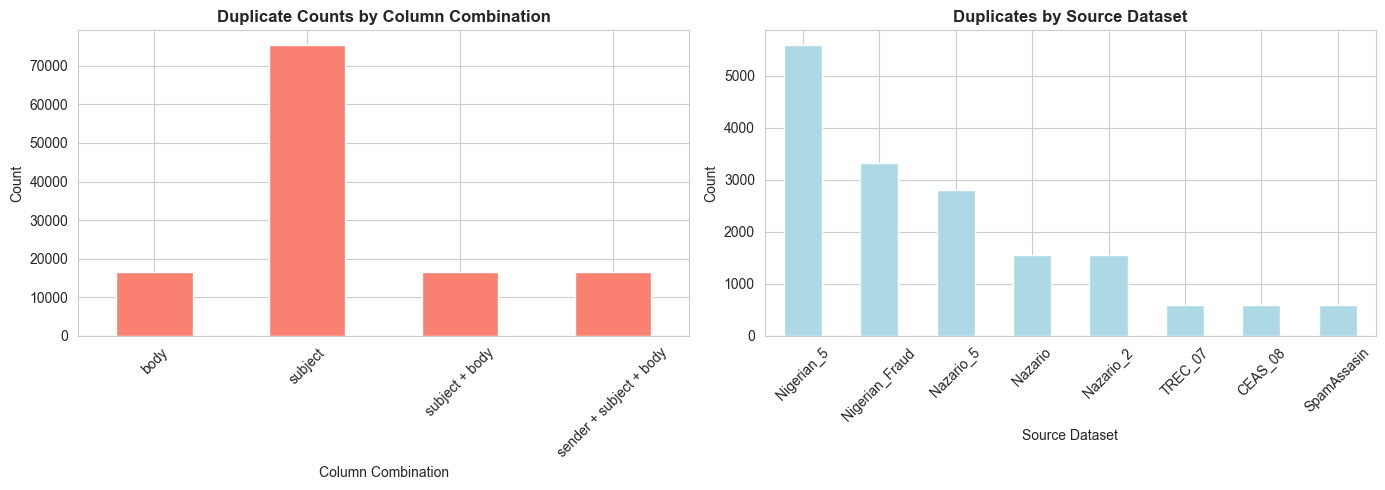


----------------------------------------------------------------------
Sample Duplicate Emails:
----------------------------------------------------------------------


,sender,subject,body,label,source_dataset
43352,Bruce D'Ambrosio <ykpbgoxj@cs.orst.edu>,[UAI] CfP: DATE05: Subtrack Real-time Systems,\t\t\t Call for Papers\n\t Subtrack on...,0,Nazario_5
427,Bruce D'Ambrosio <ykpbgoxj@cs.orst.edu>,[UAI] CfP: DATE05: Subtrack Real-time Systems,\t\t\t Call for Papers\n\t Subtrack on...,0,CEAS_08
50648,Bruce D'Ambrosio <ykpbgoxj@cs.orst.edu>,[UAI] CfP: DATE05: Subtrack Real-time Systems,\t\t\t Call for Papers\n\t Subtrack on...,0,Nigerian_5
50668,kmgxpj+iq@gatsby.ucl.ac.uk,[UAI] Three Faculty Positions in CS at Univers...,\t\t UNIVERSITY COLLEGE LONDON\n\n\t\t ...,0,Nigerian_5


In [52]:
# Exact duplicates (all columns)
exact_duplicates = email_df.duplicated().sum()
print(f"\nExact Duplicates (all columns): {exact_duplicates} ({exact_duplicates/len(email_df)*100:.2f}%)")

# Duplicates by key columns
duplicate_analysis = {
    'body': email_df.duplicated(subset=['body'], keep=False).sum(),
    'subject': email_df.duplicated(subset=['subject'], keep=False).sum(),
    'subject + body': email_df.duplicated(subset=['subject', 'body'], keep=False).sum(),
    'sender + subject + body': email_df.duplicated(subset=['sender', 'subject', 'body'], keep=False).sum()
}

print("\nDuplicates by Key Columns:")
for key, count in duplicate_analysis.items():
    print(f"  {key}: {count} ({count/len(email_df)*100:.2f}%)")

# Check if duplicates are in same or different source datasets
print("\n" + "-"*70)
print("Duplicate Distribution Across Sources:")
print("-"*70)

duplicate_mask = email_df.duplicated(subset=['subject', 'body'], keep=False)
duplicate_by_source = email_df[duplicate_mask]['source_dataset'].value_counts()
print(duplicate_by_source)

# Visualize duplicates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duplicate types
dup_data = pd.Series(duplicate_analysis)
dup_data.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Duplicate Counts by Column Combination', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Column Combination')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Duplicates by source
duplicate_by_source.plot(kind='bar', ax=axes[1], color='lightblue')
axes[1].set_title('Duplicates by Source Dataset', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Source Dataset')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Sample duplicate content
print("\n" + "-"*70)
print("Sample Duplicate Emails:")
print("-"*70)
duplicate_bodies = email_df[email_df.duplicated(subset=['body'], keep=False)].sort_values('body')
if len(duplicate_bodies) > 0:
    sample_dup = duplicate_bodies.head(4)[['sender', 'subject', 'body', 'label', 'source_dataset']]
    display(sample_dup)


#### Key Findings:
1. No exact duplicates (0%) - good!
2. 16,660 duplicate bodies (14.54%) - significant!
3. 75,346 duplicate subjects (65.76%) - very high, but subjects can be generic
4. Nigerian datasets have most duplicates (Nigerian_5: 5,592, Nigerian_Fraud: 3,332)

### REMOVING TRUE DUPLICATES (sender + subject + body)
##### Why sender + subject + body is OPTIMAL:
* Truly identical emails - exact same sender, subject, content = zero new information
* Keeps legitimate variations (same content, different senders)
* Preserves diversity while removing actual duplicates
* This is the same email sent multiple times in the dataset

In [53]:
# Store original dimensions
original_rows = len(email_df)
original_cols = email_df.shape[1]

print(f"\nOriginal Dataset Dimensions:")
print(f"  Rows: {original_rows:,}")
print(f"  Columns: {original_cols}")
print(f"  Shape: {original_rows:,} × {original_cols}")

# Remove duplicates based on sender + subject + body
email_df = email_df.drop_duplicates(subset=['sender', 'subject', 'body'], keep='first')

# New dimensions
new_rows = len(email_df)
new_cols = email_df.shape[1]
removed = original_rows - new_rows

print(f"\nAfter Removing Duplicates:")
print(f"  Rows: {new_rows:,}")
print(f"  Columns: {new_cols}")
print(f"  Shape: {new_rows:,} × {new_cols}")

print(f"\nRemoved: {removed:,} duplicate emails ({removed/original_rows*100:.2f}%)")
print(f"Retained: {new_rows:,} unique emails ({new_rows/original_rows*100:.2f}%)")

# Check label distribution after deduplication
print("\n" + "-"*70)
print("Label Distribution After Deduplication:")
print("-"*70)
label_counts_new = email_df['label'].value_counts().sort_index()
for label, count in label_counts_new.items():
    pct = count/new_rows*100
    print(f"  Label {label}: {count:,} ({pct:.2f}%)")

# Memory usage
memory_mb = email_df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory Usage: {memory_mb:.2f} MB")


Original Dataset Dimensions:
  Rows: 114,578
  Columns: 8
  Shape: 114,578 × 8

After Removing Duplicates:
  Rows: 105,077
  Columns: 8
  Shape: 105,077 × 8

Removed: 9,501 duplicate emails (8.29%)
Retained: 105,077 unique emails (91.71%)

----------------------------------------------------------------------
Label Distribution After Deduplication:
----------------------------------------------------------------------
  Label 0: 47,221 (44.94%)
  Label 1: 57,856 (55.06%)

Memory Usage: 258.89 MB


3. Data quality issues - Invalid entries, malformed data, inconsistencies

In [54]:
# 1. BASIC DATA OVERVIEW
print("\n" + "="*70)
print("1. BASIC DATA INFO")
print("="*70)
print(email_df.info())

# 2. MISSING VALUES ANALYSIS
print("\n" + "="*70)
print("2. MISSING VALUES")
print("="*70)
missing_data = pd.DataFrame({
    'Column': email_df.columns,
    'Missing_Count': email_df.isnull().sum(),
    'Missing_Percentage': (email_df.isnull().sum() / len(email_df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data.to_string(index=False))

# 3. DATA TYPE CONSISTENCY
print("\n" + "="*70)
print("3. DATA TYPE ANALYSIS")
print("="*70)
print(email_df.dtypes)

# Check if 'urls' column has consistent type across all rows
print(f"\nURLs column unique data types: {email_df['urls'].apply(type).unique()}")

# 4. LABEL VALUES CHECK
print("\n" + "="*70)
print("4. LABEL VALUES CHECK")
print("="*70)
print("Unique label values:", email_df['label'].unique())
print("Label value counts:")
print(email_df['label'].value_counts().sort_index())

# Check for any non-binary labels
invalid_labels = email_df[~email_df['label'].isin([0, 1])]
print(f"\nInvalid labels (not 0 or 1): {len(invalid_labels)}")

# 5. EMAIL ADDRESS FORMAT CHECK
print("\n" + "="*70)
print("5. EMAIL ADDRESS FORMAT CHECK")
print("="*70)

# Simple email pattern
email_pattern = r'^[^@\s]+@[^@\s]+\.[^@\s]+$'

# Check sender
invalid_senders = email_df[email_df['sender'].notna() & ~email_df['sender'].str.match(email_pattern, na=False)]
print(f"Invalid sender format: {len(invalid_senders):,} ({len(invalid_senders)/len(email_df)*100:.2f}%)")
if len(invalid_senders) > 0:
    print("\nSample invalid senders:")
    print(invalid_senders['sender'].head(10).tolist())

# Check receiver
invalid_receivers = email_df[email_df['receiver'].notna() & ~email_df['receiver'].str.match(email_pattern, na=False)]
print(f"\nInvalid receiver format: {len(invalid_receivers):,} ({len(invalid_receivers)/len(email_df)*100:.2f}%)")
if len(invalid_receivers) > 0:
    print("\nSample invalid receivers:")
    print(invalid_receivers['receiver'].head(10).tolist())

# 6. TEXT FIELD QUALITY
print("\n" + "="*70)
print("6. TEXT FIELD QUALITY")
print("="*70)

# Check for empty or whitespace-only fields
empty_subjects = email_df[email_df['subject'].isna() | (email_df['subject'].str.strip() == '')]
print(f"Empty/whitespace subjects: {len(empty_subjects):,} ({len(empty_subjects)/len(email_df)*100:.2f}%)")

empty_bodies = email_df[email_df['body'].isna() | (email_df['body'].str.strip() == '')]
print(f"Empty/whitespace bodies: {len(empty_bodies):,} ({len(empty_bodies)/len(email_df)*100:.2f}%)")

# Check body length distribution
email_df['body_length'] = email_df['body'].fillna('').str.len()
print(f"\nBody length statistics:")
print(email_df['body_length'].describe())

# Very short bodies (potential data quality issues)
very_short_bodies = email_df[email_df['body_length'] < 10]
print(f"\nVery short bodies (<10 chars): {len(very_short_bodies):,} ({len(very_short_bodies)/len(email_df)*100:.2f}%)")
if len(very_short_bodies) > 0:
    print("\nSample very short bodies:")
    print(very_short_bodies[['subject', 'body', 'label']].head(5))

# 7. DATE FORMAT CHECK
print("\n" + "="*70)
print("7. DATE FORMAT CHECK")
print("="*70)
print(f"Date column data type: {email_df['date'].dtype}")
print(f"\nSample date values:")
print(email_df['date'].dropna().head(10).tolist())

# Check for non-parseable dates
def is_valid_date(date_str):
    if pd.isna(date_str):
        return False
    try:
        pd.to_datetime(date_str)
        return True
    except:
        return False

date_validity = email_df['date'].apply(is_valid_date)
invalid_dates = email_df[~date_validity & email_df['date'].notna()]
print(f"\nInvalid date formats: {len(invalid_dates):,}")
if len(invalid_dates) > 0:
    print("\nSample invalid dates:")
    print(invalid_dates['date'].head(10).tolist())

# 8. SPECIAL CHARACTERS / ENCODING ISSUES
print("\n" + "="*70)
print("8. ENCODING ISSUES CHECK")
print("="*70)

# Check for common encoding artifacts
encoding_patterns = [r'\x00', r'�', r'\\x[0-9a-f]{2}', r'&nbsp;', r'&lt;', r'&gt;']
encoding_issues = email_df['body'].str.contains('|'.join(encoding_patterns), case=False, na=False).sum()
print(f"Emails with potential encoding issues: {encoding_issues:,} ({encoding_issues/len(email_df)*100:.2f}%)")

# Sample with encoding issues
if encoding_issues > 0:
    sample_encoding = email_df[email_df['body'].str.contains('|'.join(encoding_patterns), case=False, na=False)].head(3)
    print("\nSample bodies with encoding issues:")
    for idx, row in sample_encoding.iterrows():
        print(f"\n{row['body'][:200]}...")

# 9. DUPLICATE COLUMN VALUES (sanity check)
print("\n" + "="*70)
print("9. UNIQUENESS CHECK")
print("="*70)
for col in ['sender', 'receiver', 'subject', 'body']:
    unique_count = email_df[col].nunique()
    print(f"{col}: {unique_count:,} unique values ({unique_count/len(email_df)*100:.2f}%)")

print("\n" + "="*70)
print("DATA QUALITY EXPLORATION COMPLETE")
print("="*70)


1. BASIC DATA INFO
<class 'pandas.core.frame.DataFrame'>
Index: 105077 entries, 0 to 114577
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   sender          104738 non-null  object
 1   receiver        102645 non-null  object
 2   date            104562 non-null  object
 3   subject         104467 non-null  object
 4   body            105076 non-null  object
 5   label           105077 non-null  int64 
 6   urls            105077 non-null  object
 7   source_dataset  105077 non-null  object
dtypes: int64(1), object(7)
memory usage: 7.2+ MB
None

2. MISSING VALUES
  Column  Missing_Count  Missing_Percentage
receiver           2432                2.31
 subject            610                0.58
    date            515                0.49
  sender            339                0.32
    body              1                0.00

3. DATA TYPE ANALYSIS
sender            object
receiver          object
date          

#### KEY FINDINGS & ACTIONS:
1. EMAIL FORMAT "ISSUES" - NO ACTION NEEDED
91% "invalid" senders, 29% "invalid" receivers
Reality: These are VALID - they include display names like "John Doe <john@email.com>"

3. DATA TYPE INCONSISTENCY
URLs column has mixed types: string AND int

4. INVALID/USELESS BODIES
19 emails with <10 character bodies (dots, spaces, useless)
5 completely empty bodies

5. ENCODING ISSUES
3,421 emails (3.26%) with encoding artifacts (�, HTML entities, etc.)

6. DATE FORMATS
336 invalid dates with garbled timezone data

7. EXTREME BODY LENGTH - INVESTIGATE
Max body: 4.6 MILLION characters! (likely data corruption)


### DATA QUALITY CLEANING

In [55]:
# Store original count
original_count = len(email_df)
print(f"\nStarting with: {original_count:,} emails\n")


Starting with: 105,077 emails



In [56]:
# 1. FIX URLs DATA TYPE INCONSISTENCY
print("="*70)
print("1. FIXING URLs COLUMN DATA TYPE")
print("="*70)

print(f"Before: {email_df['urls'].apply(type).unique()}")
email_df['urls'] = email_df['urls'].astype(str)
print(f"After: {email_df['urls'].apply(type).unique()}")
print("✓ URLs column converted to string\n")

1. FIXING URLs COLUMN DATA TYPE
Before: [<class 'str'> <class 'int'>]
After: [<class 'str'>]
✓ URLs column converted to string



In [57]:
# 2. REMOVE USELESS BODIES (<10 chars or empty)print("="*70)
print("2. REMOVING USELESS BODIES")
print("="*70)

# Identify useless bodies
useless_bodies = email_df[
    (email_df['body'].isna()) |
    (email_df['body'].str.strip().str.len() < 10)
]

print(f"Emails with useless bodies: {len(useless_bodies):,}")
print("\nSample useless bodies being removed:")
print(useless_bodies[['subject', 'body', 'label']].head())

# Remove useless bodies
email_df = email_df[
    (email_df['body'].notna()) &
    (email_df['body'].str.strip().str.len() >= 10)
]

removed_useless = original_count - len(email_df)
print(f"\n✓ Removed {removed_useless:,} emails with useless bodies")
print(f"Remaining: {len(email_df):,} emails\n")

2. REMOVING USELESS BODIES
Emails with useless bodies: 25

Sample useless bodies being removed:
                                                 subject   body  label
39200  Your USAA Checking Account Untrusted Authoriza...      .      1
39260          PLS READ THE NEW USAA NEW YEAR UPDATE NOW     \n      1
39602              USAA Electronic Wire Transfer Message    . .      1
39705                  https://hurinet.or.ug/webapp/, ,       1      1
40059                   Your Account Profile Has Expired  .. ..      1

✓ Removed 25 emails with useless bodies
Remaining: 105,052 emails



In [58]:
# 3. CLEAN ENCODING ISSUES
print("="*70)
print("3. CLEANING ENCODING ISSUES")
print("="*70)

# Count before cleaning
encoding_before = email_df['body'].str.contains('�', na=False).sum()
print(f"Emails with '�' character: {encoding_before:,}")

# Clean common encoding issues
def clean_encoding(text):
    if pd.isna(text):
        return text

    # Replace common encoding artifacts
    text = text.replace('�', ' ')  # Replace replacement character
    text = text.replace('&nbsp;', ' ')  # HTML non-breaking space
    text = text.replace('&lt;', '<')  # HTML less than
    text = text.replace('&gt;', '>')  # HTML greater than
    text = text.replace('&amp;', '&')  # HTML ampersand
    text = text.replace('&quot;', '"')  # HTML quote

    # Remove null bytes
    text = text.replace('\x00', '')

    # Normalize whitespace
    text = ' '.join(text.split())

    return text

# Apply cleaning to body and subject
email_df['body'] = email_df['body'].apply(clean_encoding)
email_df['subject'] = email_df['subject'].apply(clean_encoding)

# Count after cleaning
encoding_after = email_df['body'].str.contains('�', na=False).sum()
print(f"After cleaning - Emails with '�': {encoding_after:,}")
print(f"✓ Cleaned encoding issues in {encoding_before - encoding_after:,} emails\n")

3. CLEANING ENCODING ISSUES
Emails with '�' character: 3,303
After cleaning - Emails with '�': 0
✓ Cleaned encoding issues in 3,303 emails



In [59]:
# 4. FIX INVALID DATES
print("="*70)
print("4. FIXING INVALID DATES")
print("="*70)

# Function to safely parse dates
def safe_parse_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    try:
        return pd.to_datetime(date_str)
    except:
        return pd.NaT

# Count invalid dates before
invalid_before = email_df['date'].apply(lambda x: pd.isna(safe_parse_date(x))).sum()
print(f"Invalid dates before: {invalid_before:,}")

# Parse dates and set invalid to NaT
email_df['date'] = email_df['date'].apply(safe_parse_date)

# Count invalid dates after (now NaT)
invalid_after = email_df['date'].isna().sum()
print(f"Invalid dates after (set to NaT): {invalid_after:,}")
print(f"✓ Converted date column to datetime, {invalid_after:,} invalid dates set to NaT\n")

4. FIXING INVALID DATES
Invalid dates before: 850
Invalid dates after (set to NaT): 850
✓ Converted date column to datetime, 850 invalid dates set to NaT



In [60]:
# 5. INVESTIGATE EXTREME BODY LENGTH
print("="*70)
print("3. INVESTIGATING EXTREME BODY LENGTH")
print("="*70)

# Recalculate body length after removing useless bodies
email_df['body_length'] = email_df['body'].str.len()

print("\nBody Length Statistics:")
print(email_df['body_length'].describe())

# Find extreme outliers
print("\nTop 10 Longest Bodies:")
longest_bodies = email_df.nlargest(10, 'body_length')[['subject', 'body_length', 'label', 'source_dataset']]
print(longest_bodies)

# Check distribution of very long bodies
very_long = email_df[email_df['body_length'] > 100000]
print(f"\n✓ Emails with body length > 100,000 chars: {len(very_long):,}")
if len(very_long) > 0:
    print("\nDistribution by label:")
    print(very_long['label'].value_counts())
    print("\nDistribution by source:")
    print(very_long['source_dataset'].value_counts())

    # Sample content from extremely long body
    print("\n" + "-"*70)
    print("Sample from longest body (first 500 chars):")
    print("-"*70)
    longest_idx = email_df['body_length'].idxmax()
    print(f"Subject: {email_df.loc[longest_idx, 'subject']}")
    print(f"Length: {email_df.loc[longest_idx, 'body_length']:,} characters")
    print(f"Label: {email_df.loc[longest_idx, 'label']}")
    print(f"\nBody preview:\n{email_df.loc[longest_idx, 'body'][:500]}...")


3. INVESTIGATING EXTREME BODY LENGTH

Body Length Statistics:
count    105052.00
mean       1700.31
std       15198.70
min           8.00
25%         382.00
50%         811.00
75%        1826.00
max     4560709.00
Name: body_length, dtype: float64

Top 10 Longest Bodies:
                                                 subject  body_length  label  \
39154  DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA      4560709      1   
39687                          someone has your password      1023577      1   
46525                           Line Separator Character       778816      0   
96844    [PATCH 1/2] Commit generated prototype headers.       641682      0   
59050  =?iso-2022-jp?B?GyRCRnxLXDhsJE43b0w+IUolNSVWJT...       299197      0   
46385                      I don't know why this is.<br>       277016      0   
59415            May I have a moment of your Time PLEASE       230849      1   
59387  =?big5?Q?=A7K=B6O=B5L=AD=AD=A6=B8=A5=F4=A5=B4=...       184159      1   
59067   

#### Key Findings:

* Only 23 emails (0.02%) are extremely long
* Mix of labels (15 legit, 8 phishing)
* Mostly from TREC_07 (10) and SpamAssassin (6)
* These are likely mail system artifacts or batch exports

COMBINED CLEANING: IQR 2.0 + SPECIFIC CORRUPTION PATTERNS

In [63]:
# Calculate body lengths first for analysis
email_df['body_length'] = email_df['body'].str.len()
original_count = len(email_df)
print(f"\nStarting with: {original_count:,} emails")


Starting with: 100,038 emails


In [ ]:
# STEP 1: REMOVE STATISTICAL OUTLIERS USING IQR (MULTIPLIER 2.0)
# Calculate IQR
Q1 = email_df['body_length'].quantile(0.25)
Q3 = email_df['body_length'].quantile(0.75)
IQR = Q3 - Q1

# Use multiplier of 2.0 for aggressive outlier removal
multiplier = 2.0
upper_bound = Q3 + (multiplier * IQR)

print(f"\nIQR Statistics:")
print(f"  Q1 (25th percentile): {Q1:,.0f} characters")
print(f"  Q3 (75th percentile): {Q3:,.0f} characters")
print(f"  IQR: {IQR:,.0f} characters")
print(f"  Multiplier: {multiplier}")
print(f"  Upper Bound: {upper_bound:,.0f} characters")

# Identify IQR outliers
iqr_outliers = email_df[email_df['body_length'] > upper_bound]
print(f"\n✓ IQR outliers detected: {len(iqr_outliers):,} ({len(iqr_outliers)/len(email_df)*100:.3f}%)")

# Show sample IQR outliers
print("\nSample IQR outliers (Top 3 longest):")
for idx, row in iqr_outliers.nlargest(3, 'body_length').iterrows():
    print(f"  - Subject: {row['subject'][:60]}... | Length: {row['body_length']:,} | Label: {row['label']}")

# Remove IQR outliers
email_df = email_df[email_df['body_length'] <= upper_bound]
iqr_removed = original_count - len(email_df)

print(f"\n✓ Removed {iqr_removed:,} IQR outliers")
print(f"Remaining: {len(email_df):,} emails")

In [64]:
# STEP 2: REMOVE SPECIFIC CORRUPTION PATTERNS
before_pattern_removal = len(email_df)

# 1. Remove mail folder metadata corruption
metadata_corruption = email_df['subject'].str.contains(
    "DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA",
    case=False,
    na=False
)

# 2. Remove emails that are clearly concatenated mail dumps (multiple "From:" headers pattern)
mail_dump_pattern = email_df['body'].str.count(r'From [0-9]+@').fillna(0) > 5

# 3. Alternative mail dump detection: multiple "Return-Path:" headers
return_path_dumps = email_df['body'].str.count(r'Return-Path:').fillna(0) > 5

# Combine all corruption conditions
corrupted = metadata_corruption | mail_dump_pattern | return_path_dumps

print(f"\nCorrupted emails detected by type:")
print(f"  1. Mail folder metadata: {metadata_corruption.sum():,}")
print(f"  2. Mail dumps (5+ 'From' patterns): {mail_dump_pattern.sum():,}")
print(f"  3. Mail dumps (5+ 'Return-Path'): {return_path_dumps.sum():,}")
print(f"  {'='*50}")
print(f"  Total unique corrupted emails: {corrupted.sum():,} ({corrupted.sum()/len(email_df)*100:.3f}%)")

# Show corrupted emails if any
if corrupted.sum() > 0:
    corrupted_emails = email_df[corrupted].copy()
    corrupted_emails = corrupted_emails.sort_values('body_length', ascending=False)

    print("\nTop 3 corrupted emails being removed:")
    for i, (idx, row) in enumerate(corrupted_emails.head(3).iterrows(), 1):
        print(f"\n  {i}. Subject: {row['subject'][:60]}...")
        print(f"     Length: {row['body_length']:,} | Label: {row['label']} | Source: {row['source_dataset']}")
        print(f"     Preview: {row['body'][:150]}...")

# Remove corrupted emails
email_df = email_df[~corrupted]
pattern_removed = before_pattern_removal - len(email_df)

print(f"\n✓ Removed {pattern_removed:,} corrupted emails")
print(f"Remaining: {len(email_df):,} emails")

# Drop temporary body_length column
email_df = email_df.drop('body_length', axis=1)


Corrupted emails detected by type:
  1. Mail folder metadata: 0
  2. Mail dumps (5+ 'From' patterns): 0
  3. Mail dumps (5+ 'Return-Path'): 0
  Total unique corrupted emails: 0 (0.000%)

✓ Removed 0 corrupted emails
Remaining: 100,038 emails


# FINAL DATASET INFORMATION

In [67]:
print(f"\nDimensions: {email_df.shape[0]:,} rows × {email_df.shape[1]} columns")
print(f"Memory Usage: {email_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nColumns:")
for i, col in enumerate(email_df.columns, 1):
    print(f"  {i}. {col}")



Dimensions: 100,038 rows × 8 columns
Memory Usage: 170.56 MB

Columns:
  1. sender
  2. receiver
  3. date
  4. subject
  5. body
  6. label
  7. urls
  8. source_dataset


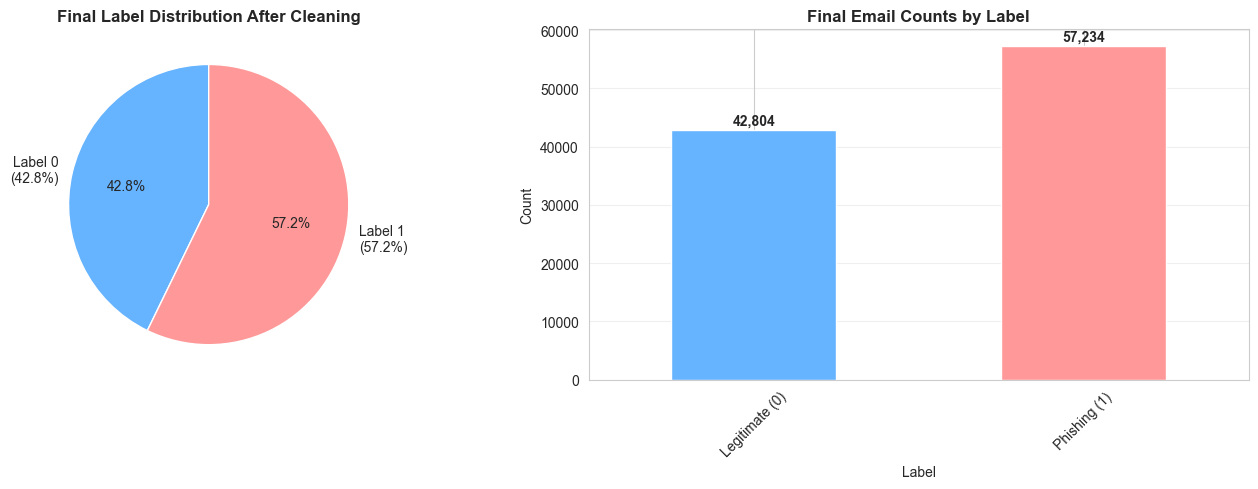

In [75]:

# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(label_counts, labels=[f'Label {i}\n({label_pct[i]:.1f}%)' for i in label_counts.index],
            autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
axes[0].set_title('Final Label Distribution After Cleaning', fontsize=12, fontweight='bold')

# Bar chart
label_counts.plot(kind='bar', ax=axes[1], color=['#66b3ff', '#ff9999'])
axes[1].set_title('Final Email Counts by Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, (label, count) in enumerate(label_counts.items()):
    axes[1].text(i, count + 500, f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### INVESTIGATING REMAINING EMAIL BODY LENGTHS
* Lets re investigate all the emails with big body lengt

In [84]:
# Calculate body lengths
email_df['body_length'] = email_df['body'].str.len()

# Overall statistics
print("\nBody Length Statistics:")
print(email_df['body_length'].describe())

print(f"\nMin body length: {email_df['body_length'].min():,} characters")
print(f"Max body length: {email_df['body_length'].max():,} characters")
print(f"Mean body length: {email_df['body_length'].mean():,.2f} characters")
print(f"Median body length: {email_df['body_length'].median():,} characters")


Body Length Statistics:
count   100038.00
mean      1159.79
std       1070.19
min          8.00
25%        357.00
50%        768.00
75%       1634.00
max       4714.00
Name: body_length, dtype: float64

Min body length: 8 characters
Max body length: 4,714 characters
Mean body length: 1,159.79 characters
Median body length: 768.0 characters


### TOP AND BOTTOM 5 LONGEST EMAILS REMAINING

In [85]:
print("\n" + "="*70)
print("TOP 5 LONGEST EMAILS REMAINING IN DATASET:")
print("="*70)

longest_emails = email_df.nlargest(5, 'body_length')

for i, (idx, row) in enumerate(longest_emails.iterrows(), 1):
    print(f"\n{'-'*70}")
    print(f"Rank: #{i}")
    print(f"Subject: {row['subject']}")
    print(f"Body Length: {row['body_length']:,} characters")
    print(f"Label: {row['label']} ({'Phishing' if row['label'] == 1 else 'Legitimate'})")
    print(f"Source: {row['source_dataset']}")
    print(f"Sender: {row['sender']}")
    print(f"\nBody Preview (first 500 chars):")
    print(row['body'][:500] + "...")
    print(f"\nBody Preview (last 200 chars):")
    print("..." + row['body'][-200:])

print("\n" + "="*70)
print("BOTTOM 5 SHORTEST EMAILS REMAINING IN DATASET:")
print("="*70)

shortest_emails = email_df.nsmallest(5, 'body_length')

for i, (idx, row) in enumerate(shortest_emails.iterrows(), 1):
    print(f"\n{'-'*70}")
    print(f"Rank: #{i}")
    print(f"Subject: {row['subject']}")
    print(f"Body Length: {row['body_length']:,} characters")
    print(f"Label: {row['label']} ({'Phishing' if row['label'] == 1 else 'Legitimate'})")
    print(f"Source: {row['source_dataset']}")
    print(f"Sender: {row['sender']}")
    print(f"\nFull Body:")
    print(f'"{row["body"]}"')



TOP 5 LONGEST EMAILS REMAINING IN DATASET:

----------------------------------------------------------------------
Rank: #1
Subject: Re: [UAI] CIS'06 Call-for-Papers (Extended Paper Submission Due Date: June 30, 2006)...
Body Length: 4,714 characters
Label: 0 (Legitimate)
Source: CEAS_08
Sender: CIS CIS <pym@Comp.HKBU.Edu.HK>

Body Preview (first 500 chars):
Dear Colleagues, By request of many prospective authors, the paper submission due date of CIS'06 has been extended to *** June 30, 2006 ***. We sincerely apologize if you receive this call for papers multiple times. ***************************************************************************************************** URL: http://cis2006.gdut.edu.cn (*** Paper Extended Submission Due Date: June 30, 2006 ***) ******************************************************************************************...

Body Preview (last 200 chars):
...twork Application Enquiry and Information: CIS2006 Secretariat Faculty of Applied Mathematics Guang

### DISTRIBUTION ANALYSIS

In [86]:
# DISTRIBUTION ANALYSIS
# Percentiles
percentiles = [50, 75, 90, 95, 99, 99.9, 99.99]
print("\nPercentiles:")
for p in percentiles:
    value = email_df['body_length'].quantile(p/100)
    print(f"  {p}th percentile: {value:,.0f} characters")

# Count emails in different length ranges
ranges = [
    (0, 100, "Very Short (0-100)"),
    (100, 500, "Short (100-500)"),
    (500, 1000, "Medium (500-1K)"),
    (1000, 5000, "Long (1K-5K)"),
    (5000, 10000, "Very Long (5K-10K)"),
    (10000, 50000, "Extremely Long (10K-50K)"),
    (50000, float('inf'), "Mega Long (>50K)")
]

print("\nEmails by Body Length Range:")
for min_len, max_len, label in ranges:
    count = ((email_df['body_length'] >= min_len) & (email_df['body_length'] < max_len)).sum()
    pct = count / len(email_df) * 100
    print(f"  {label}: {count:,} ({pct:.2f}%)")



Percentiles:
  50th percentile: 768 characters
  75th percentile: 1,634 characters
  90th percentile: 2,927 characters
  95th percentile: 3,648 characters
  99th percentile: 4,215 characters
  99.9th percentile: 4,661 characters
  99.99th percentile: 4,708 characters

Emails by Body Length Range:
  Very Short (0-100): 4,289 (4.29%)
  Short (100-500): 28,309 (28.30%)
  Medium (500-1K): 26,955 (26.94%)
  Long (1K-5K): 40,485 (40.47%)
  Very Long (5K-10K): 0 (0.00%)
  Extremely Long (10K-50K): 0 (0.00%)
  Mega Long (>50K): 0 (0.00%)


### VISUALIZING BODY LENGTH DISTRIBUTION

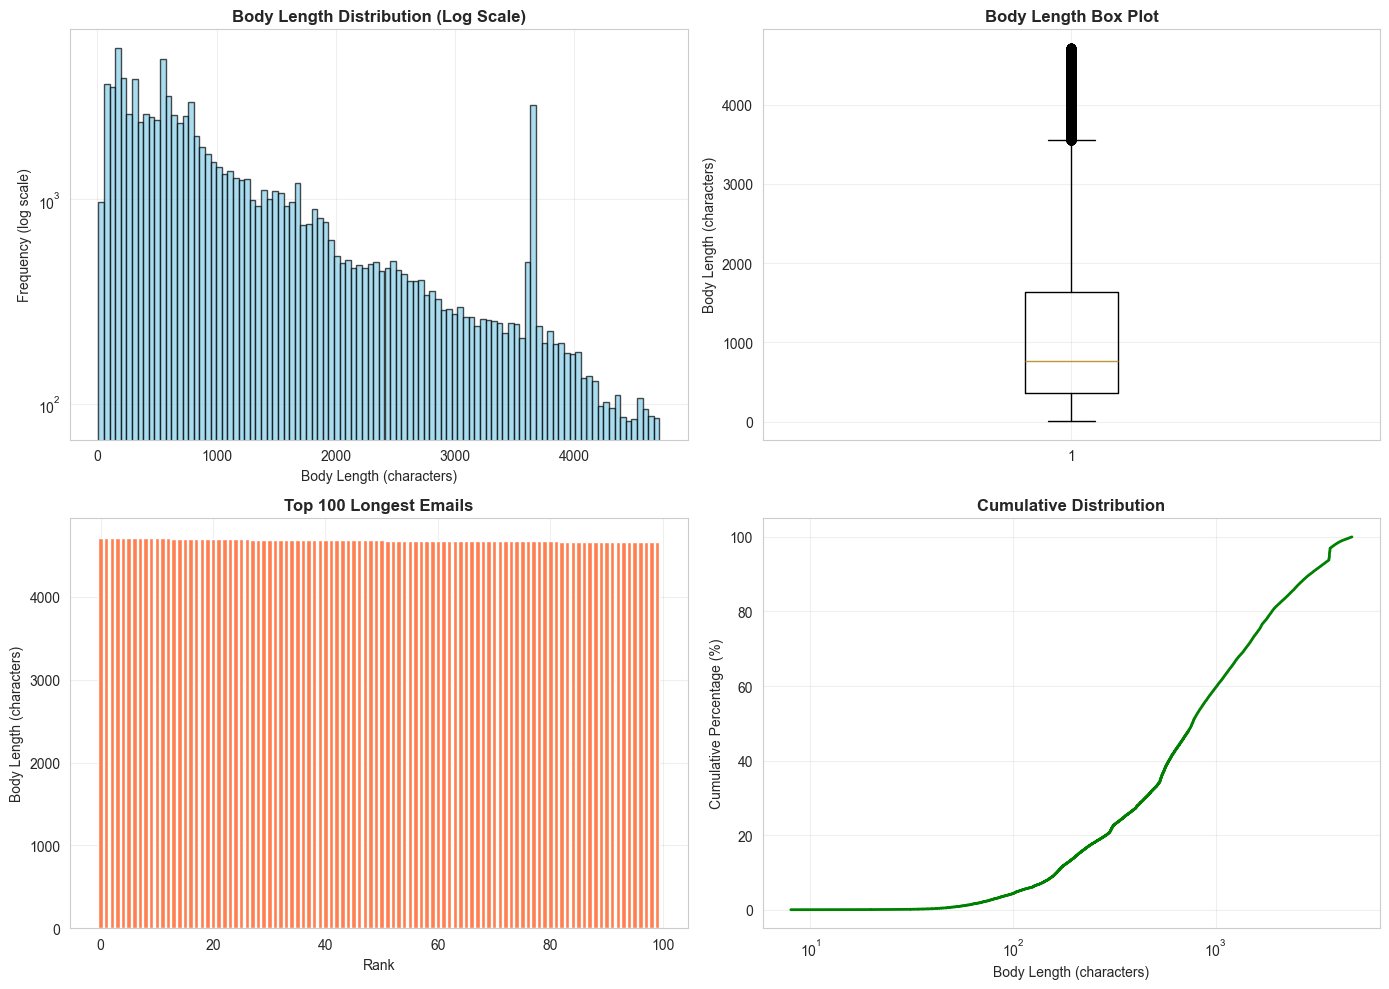

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram with log scale
axes[0, 0].hist(email_df['body_length'], bins=100, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Body Length Distribution (Log Scale)', fontweight='bold')
axes[0, 0].set_xlabel('Body Length (characters)')
axes[0, 0].set_ylabel('Frequency (log scale)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot
axes[0, 1].boxplot(email_df['body_length'], vert=True)
axes[0, 1].set_title('Body Length Box Plot', fontweight='bold')
axes[0, 1].set_ylabel('Body Length (characters)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Top 100 longest emails
top_100 = email_df.nlargest(100, 'body_length')['body_length']
axes[1, 0].bar(range(len(top_100)), top_100.values, color='coral')
axes[1, 0].set_title('Top 100 Longest Emails', fontweight='bold')
axes[1, 0].set_xlabel('Rank')
axes[1, 0].set_ylabel('Body Length (characters)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative distribution
sorted_lengths = np.sort(email_df['body_length'])
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
axes[1, 1].plot(sorted_lengths, cumulative, linewidth=2, color='green')
axes[1, 1].set_title('Cumulative Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Body Length (characters)')
axes[1, 1].set_ylabel('Cumulative Percentage (%)')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Drop temporary column
email_df = email_df.drop('body_length', axis=1)
